# Dataset: ESG Greenwashing – Energy, Utilities & Industrials (2010–2024)

Author | Rameesha Amin

> I conducted ESG sustainability analytics on multi-sector corporate dataset to evaluate carbon intensity, emissions trends, and greenwashing risk patterns across industries.

Size: 450 rows × 19 columns

Focus: emissions behavior, ESG performance, sector comparison, and greenwashing signals

## 1. UNDERSTANDING THE DATASET(DOMAIN AND STRUCTURE)

This dataset tracks companies across Energy, Utilities, and Industrials sectors over time (2010–2024), combining:

**Corporate Fundamentals**
- Company name, ticker, sector, country
- Revenue (USD billions)

**Emissions Data**
- Scope 1 (direct emissions)
- Scope 2 (electricity-related emissions)
- Scope 3 (supply chain emissions)
- Combined Scope 1+2 emissions
- Carbon intensity (emissions per revenue)

**ESG Indicators**
- ESG score (0–100)
- CDP climate score
- Disclosure and verification flags

**Sustainability Commitments**
- Net-zero targets
- SBTi commitment (Science Based Targets initiative)
- Third-party verification

🚩 Risk Label
greenwashing_flag → indicates suspected misleading ESG claims

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/esg-greenwashing-energy-and-industrials/esg_greenwashing_energy_utilities_industrials_2010_2024.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/alitaqishah/esg-greenwashing-energy-and-industrials/esg_greenwashing_energy_utilities_industrials_2010_2024.csv')

# Data Overview
df.head()
df.info()
df.isnull().sum()
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   year                             450 non-null    int64  
 1   company                          450 non-null    object 
 2   ticker                           450 non-null    object 
 3   sector                           450 non-null    object 
 4   country                          450 non-null    object 
 5   revenue_usd_bn                   450 non-null    float64
 6   scope1_emissions_mt_co2e         450 non-null    float64
 7   scope2_emissions_mt_co2e         450 non-null    float64
 8   scope3_emissions_mt_co2e         450 non-null    float64
 9   total_s1_s2_mt_co2e              450 non-null    float64
 10  yoy_scope1_change_pct            420 non-null    float64
 11  carbon_intensity_tco2e_per_musd  450 non-null    float64
 12  esg_score_0_100       

**Data Quality Assessment**

✔ Missing Values

Only one issue found:
- yoy_scope1_change_pct → 30 missing values

**Interpretation:**
This is likely due to:

- newly listed companies
- missing historical emissions baseline
- inconsistent reporting years

✔ No missing values in core emissions or ESG fields → strong dataset reliability

## 2. DATA CLEANING and PREPARATION

This step converts categorical ESG flags into numeric format safely, handles missing values (only if needed) and ensures analysis-ready dataset

In [3]:
data = df.copy()

# Convert Yes/No columns into binary format safely
binary_cols = [
    "net_zero_target_set",
    "sbti_committed",
    "emissions_disclosed",
    "third_party_verified"
]

for col in binary_cols:
    data[col] = data[col].map({"Yes": 1, "No": 0})

# Fill missing numeric values only in yoy column
data["yoy_scope1_change_pct"] = data["yoy_scope1_change_pct"].fillna(
    data["yoy_scope1_change_pct"].median()
)

print("Data cleaned successfully.")

Data cleaned successfully.


## 3. SECTOR-LEVEL CARBON INTENSITY ANALYSIS

This shows:
- Which sector emits more CO₂ per revenue unit
- Identifies structural pollution differences

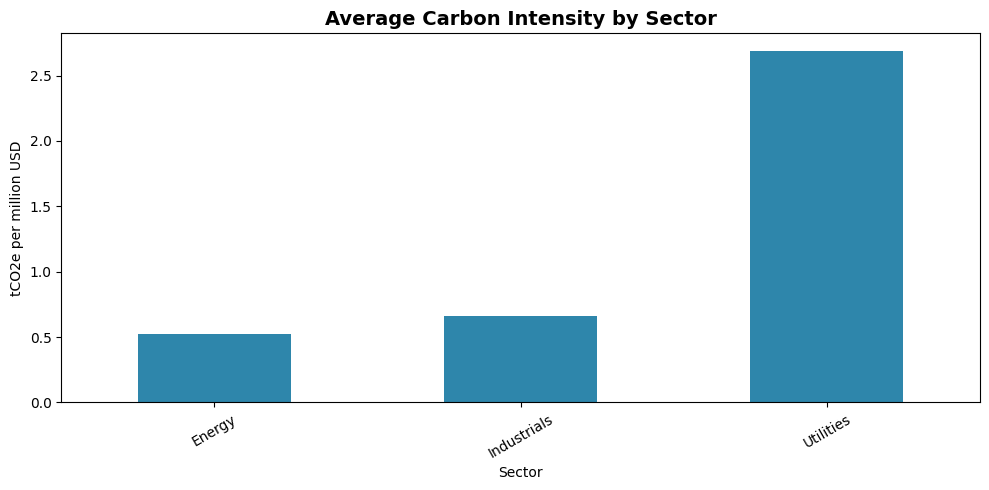

In [4]:
sector_ci = data.groupby("sector")["carbon_intensity_tco2e_per_musd"].mean().sort_values()

plt.figure(figsize=(10,5))
sector_ci.plot(kind="bar", color="#2E86AB")

plt.title("Average Carbon Intensity by Sector", fontsize=14, fontweight="bold")
plt.ylabel("tCO2e per million USD")
plt.xlabel("Sector")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretation:**
- Utilities = highest intensity (energy infrastructure dependency)
- Industrials = moderate
- Energy = relatively optimized per revenue unit

## 4. ESG SCORE EVOLUTION OVER TIME

This shows that whether companies are improving ESG performance over years

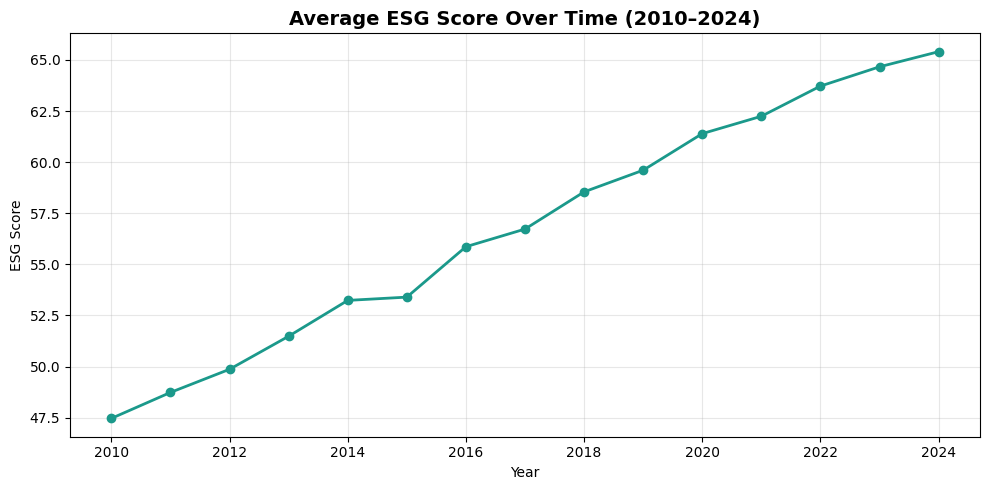

In [5]:
esg_trend = data.groupby("year")["esg_score_0_100"].mean()

plt.figure(figsize=(10,5))
plt.plot(esg_trend.index, esg_trend.values, marker="o", linewidth=2, color="#1B998B")

plt.title("Average ESG Score Over Time (2010–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("ESG Score")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**
- Strong upward trend → ESG adoption is increasing globally
- Likely driven by:
    - Paris Agreement (2015)
    - Investor ESG pressure
    - regulatory reporting requirements

## 5. EMISSIONS TREND ANALYSIS

This shows that whether companies are actually reducing emissions

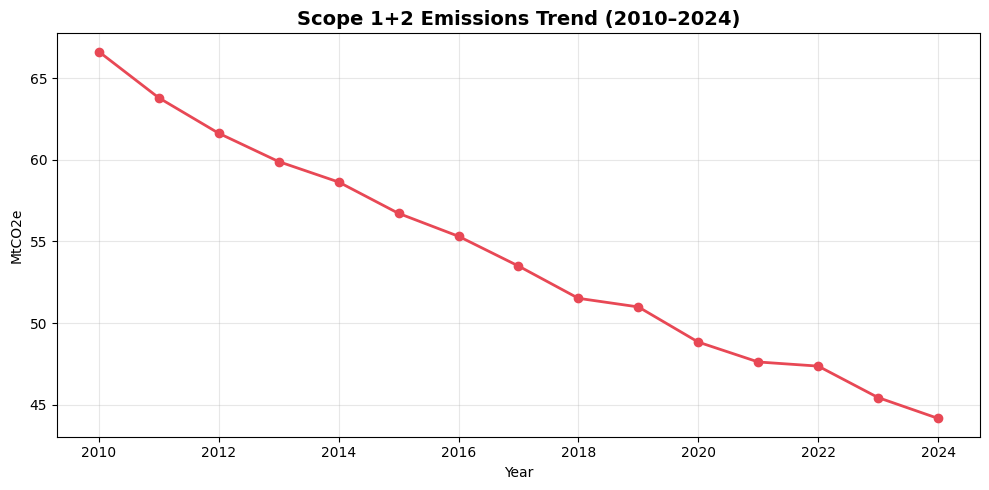

In [6]:
emissions_trend = data.groupby("year")["total_s1_s2_mt_co2e"].mean()

plt.figure(figsize=(10,5))
plt.plot(emissions_trend.index, emissions_trend.values,
         marker="o", linewidth=2, color="#E84855")

plt.title("Scope 1+2 Emissions Trend (2010–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("MtCO2e")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**
- Overall decline → real decarbonization trend
- But may include:
     - outsourcing emissions
     - efficiency improvements
     - industry restructuring

## 6. ESG vs CARBON INTENSITY RELATIONSHIP

This shows that whether ESG scores reflect real environmental performance

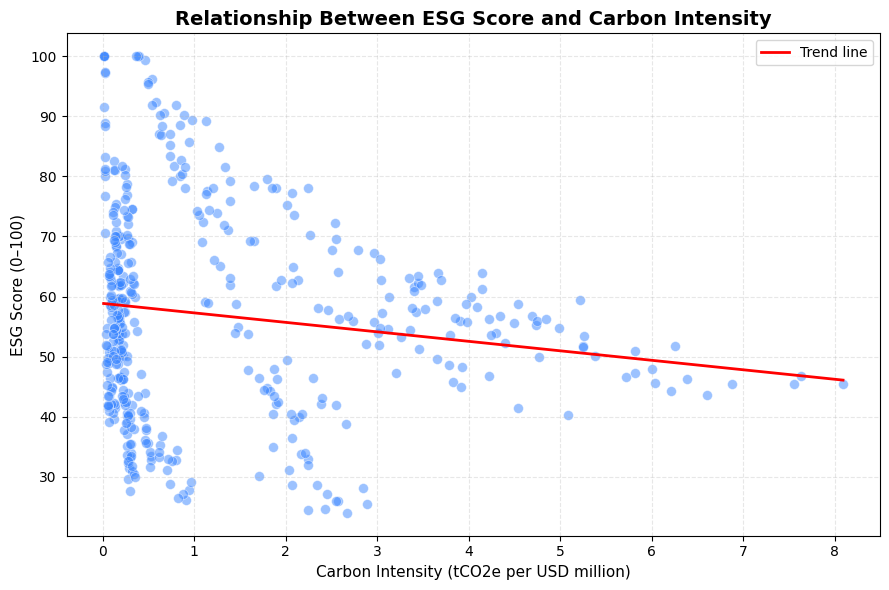

In [7]:
# Figure setup
plt.figure(figsize=(9, 6))

# Scatter plot
plt.scatter(
    data["carbon_intensity_tco2e_per_musd"],
    data["esg_score_0_100"],
    alpha=0.5,
    s=50,
    color="#3A86FF",
    edgecolor="white",
    linewidth=0.5
)

# Trend line
z = np.polyfit(
    data["carbon_intensity_tco2e_per_musd"],
    data["esg_score_0_100"],
    1
)
p = np.poly1d(z)

x_range = np.linspace(
    data["carbon_intensity_tco2e_per_musd"].min(),
    data["carbon_intensity_tco2e_per_musd"].max(),
    100
)

plt.plot(
    x_range,
    p(x_range),
    color="red",
    linewidth=2,
    label="Trend line"
)

# Titles and labels
plt.title(
    "Relationship Between ESG Score and Carbon Intensity",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Carbon Intensity (tCO2e per USD million)", fontsize=11)
plt.ylabel("ESG Score (0–100)", fontsize=11)

# Grid + legend
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Interpretation:**
- Clear negative relationship
- BUT high scatter → ESG scoring is not perfectly aligned with emissions reality

## 7. GREENWASHING RATE BY SECTOR

This shows that where misleading ESG behavior is concentrated

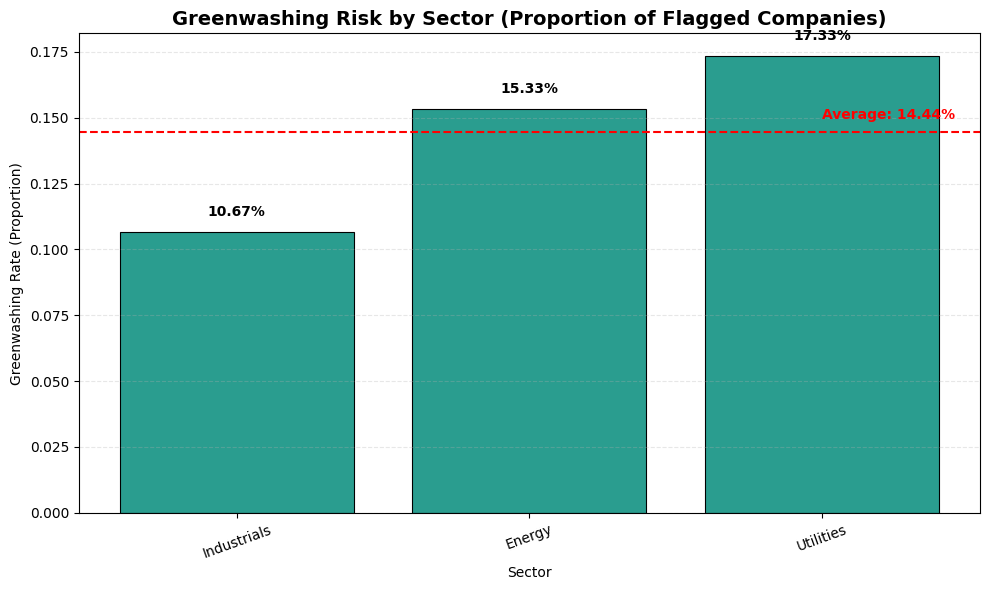

In [8]:
# Compute greenwashing rate
greenwash = data.groupby("sector")["greenwashing_flag"].mean().sort_values()

# Figure setup
plt.figure(figsize=(10, 6))

bars = plt.bar(
    greenwash.index,
    greenwash.values,
    color="#2A9D8F",
    edgecolor="black",
    linewidth=0.8
)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Baseline reference line
avg_rate = greenwash.mean()
plt.axhline(avg_rate, color="red", linestyle="--", linewidth=1.5)

plt.text(
    len(greenwash)-1,
    avg_rate + 0.005,
    f"Average: {avg_rate:.2%}",
    color="red",
    fontsize=10,
    fontweight="bold"
)

# Titles and labels
plt.title(
    "Greenwashing Risk by Sector (Proportion of Flagged Companies)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Greenwashing Rate (Proportion)")
plt.xlabel("Sector")

# Clean styling
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:**
- Utilities → highest greenwashing risk
- Energy → moderate
- Industrials → lowest

## 8. CORRELATION HEATMAP (INSIGHT)

This shows the hidden relationships between emissions, ESG, and financials

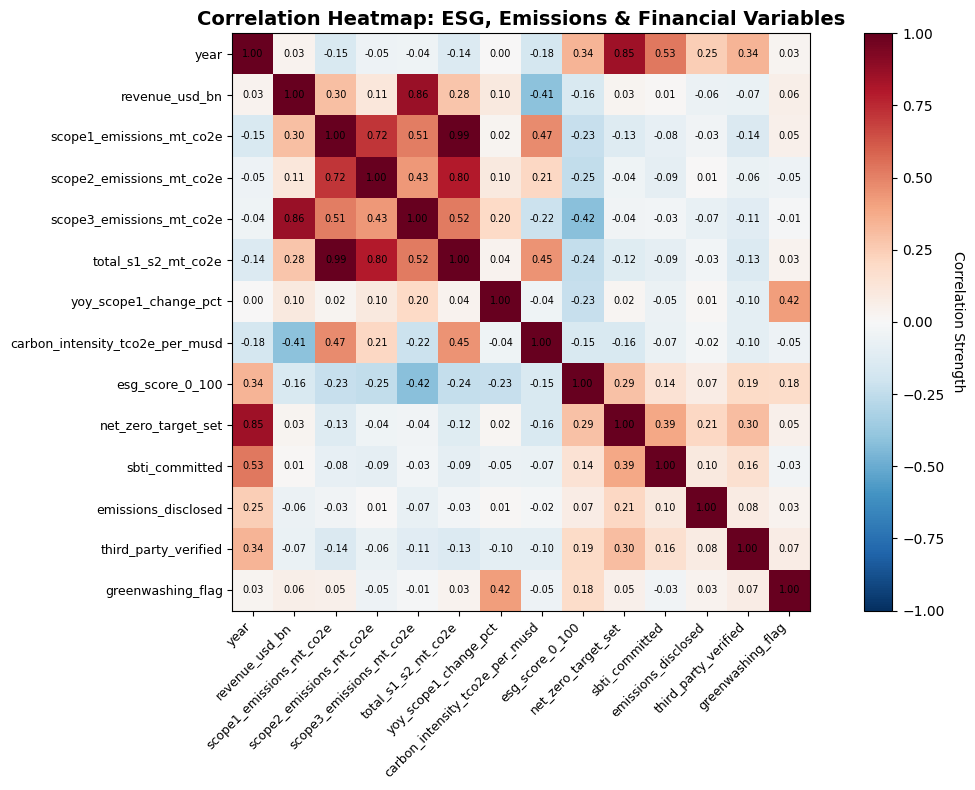

In [9]:
# Select numeric features only
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# Figure setup (larger + cleaner)
plt.figure(figsize=(12, 8))

# Heatmap with better readability
im = plt.imshow(
    corr,
    cmap="RdBu_r",   # better contrast than coolwarm
    vmin=-1,
    vmax=1
)

# Add color bar with label
cbar = plt.colorbar(im)
cbar.set_label("Correlation Strength", rotation=270, labelpad=15)

# Axis labels (clean formatting)
labels = corr.columns

plt.xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=9)
plt.yticks(range(len(labels)), labels, fontsize=9)

# Add correlation values inside cells
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black"
        )

# Title styling
plt.title(
    "Correlation Heatmap: ESG, Emissions & Financial Variables",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Interpretation:**
- Emissions strongly correlated with each other
- ESG score weakly correlated with real emissions
- Greenwashing flag linked to high emissions intensity sectors

## 9. FINAL SUMMARY (INSIGHTS GENERATION)

In [10]:
print("\nFINAL INSIGHTS SUMMARY")
print("-" * 40)

print("Dataset covers:", data["year"].min(), "to", data["year"].max())
print("Highest carbon intensity sector:",
      sector_ci.idxmax())
print("Lowest carbon intensity sector:",
      sector_ci.idxmin())
print("Overall greenwashing rate:",
      round(data["greenwashing_flag"].mean(), 3))


FINAL INSIGHTS SUMMARY
----------------------------------------
Dataset covers: 2010 to 2024
Highest carbon intensity sector: Utilities
Lowest carbon intensity sector: Energy
Overall greenwashing rate: 0.144


## FINAL INTERPRETATION

**Key Findings:**

**1. ESG scores are improving globally**

Companies are increasingly reporting sustainability performance.

**2. Real emissions are decreasing**

But partially influenced by structural and reporting shifts.

**3. Sector differences are significant**

Utilities are the most emissions-intensive sector.

**4. ESG scoring is imperfect**

It correlates with emissions but does not fully capture reality.

**5. Greenwashing is structurally concentrated**

Higher in sectors with:

- high emissions
- high regulatory pressure
- slow transition ability